In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

In [46]:
data=np.array([[3,4],[2,8],[6,9],[10,12]])

In [47]:
data

array([[ 3,  4],
       [ 2,  8],
       [ 6,  9],
       [10, 12]])

## standarization of the data


In [48]:
(3+2+6+10)/4

5.25

In [49]:
(4+8+9+12)/4

8.25

In [50]:
meanbycol=np.mean(data,axis=0)

In [51]:
stdbycol=np.std(data,axis=0)

In [52]:
scaled_data=(data-meanbycol)/stdbycol

In [53]:
scaled_data

array([[-0.7228974 , -1.4852969 ],
       [-1.04418513, -0.08737041],
       [ 0.2409658 ,  0.26211122],
       [ 1.52611672,  1.31055608]])

In [54]:
# from the library we will get the same data 
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit_transform(data)

array([[-0.7228974 , -1.4852969 ],
       [-1.04418513, -0.08737041],
       [ 0.2409658 ,  0.26211122],
       [ 1.52611672,  1.31055608]])

## calculate covariance matrix from the scaled data

In [55]:
cov_matrix=np.cov(scaled_data.T)   #for the transpose(T)

In [56]:
eig_val,eig_vec=eig(cov_matrix)

In [57]:
eig_val

array([2.40938985+0.j, 0.25727682+0.j])

In [58]:
data       

array([[ 3,  4],
       [ 2,  8],
       [ 6,  9],
       [10, 12]])

In [59]:
eig_vec

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [60]:
eig_vec.T.dot(scaled_data.T).T     #manual step

array([[-1.56142916, -0.53909786],
       [-0.80013059,  0.67657018],
       [ 0.35572917,  0.01495207],
       [ 2.00583058, -0.15242439]])

In [61]:
from sklearn.decomposition import PCA        
pca=PCA()
pca.fit_transform(scaled_data)

array([[-1.56142916, -0.53909786],
       [-0.80013059,  0.67657018],
       [ 0.35572917,  0.01495207],
       [ 2.00583058, -0.15242439]])

In [62]:
df=pd.read_csv("https://raw.githubusercontent.com/lundquist-ecology-lab/biostatistics/main/example_data/iris.csv")

In [63]:
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [64]:
new_df=df.drop(labels=['Sepal.Length','Species'],axis=1)

In [65]:
df.isnull().sum()

Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

In [66]:
# scaling of the data

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [67]:
scaled_df=scaler.fit_transform(new_df)


In [68]:
scaled_df

array([[ 1.01900435e+00, -1.34022653e+00, -1.31544430e+00],
       [-1.31979479e-01, -1.34022653e+00, -1.31544430e+00],
       [ 3.28414053e-01, -1.39706395e+00, -1.31544430e+00],
       [ 9.82172869e-02, -1.28338910e+00, -1.31544430e+00],
       [ 1.24920112e+00, -1.34022653e+00, -1.31544430e+00],
       [ 1.93979142e+00, -1.16971425e+00, -1.05217993e+00],
       [ 7.88807586e-01, -1.34022653e+00, -1.18381211e+00],
       [ 7.88807586e-01, -1.28338910e+00, -1.31544430e+00],
       [-3.62176246e-01, -1.34022653e+00, -1.31544430e+00],
       [ 9.82172869e-02, -1.28338910e+00, -1.44707648e+00],
       [ 1.47939788e+00, -1.28338910e+00, -1.31544430e+00],
       [ 7.88807586e-01, -1.22655167e+00, -1.31544430e+00],
       [-1.31979479e-01, -1.34022653e+00, -1.44707648e+00],
       [-1.31979479e-01, -1.51073881e+00, -1.44707648e+00],
       [ 2.16998818e+00, -1.45390138e+00, -1.31544430e+00],
       [ 3.09077525e+00, -1.28338910e+00, -1.05217993e+00],
       [ 1.93979142e+00, -1.39706395e+00

In [69]:
scaled_df=pd.DataFrame(data=scaled_df,columns=new_df.columns)

In [70]:
scaled_df

,Sepal.Width,Petal.Length,Petal.Width
0,1.019004,-1.340227,-1.315444
1,-0.131979,-1.340227,-1.315444
2,0.328414,-1.397064,-1.315444
3,0.098217,-1.283389,-1.315444
4,1.249201,-1.340227,-1.315444
...,...,...,...
145,-0.131979,0.819596,1.448832
146,-1.282963,0.705921,0.922303
147,-0.131979,0.819596,1.053935
148,0.788808,0.933271,1.448832


In [75]:
from sklearn.decomposition import PCA

pca1 = PCA()
X_pca = pca1.fit_transform(scaled_df.T)


In [77]:
pca1

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [76]:
X_pca

array([[ 1.36038653e+01, -3.78374334e-02, -2.11106746e-15],
       [-7.03555980e+00, -1.63350708e+00, -2.11106746e-15],
       [-6.56830552e+00,  1.67134451e+00, -2.11106746e-15]])

In [78]:
pc_df=pd.DataFrame(data=X_pca)

In [79]:
pc_df

,0,1,2
0,13.603865,-0.037837,-2.111067e-15
1,-7.035560,-1.633507,-2.111067e-15
2,-6.568306,1.671345,-2.111067e-15


In [81]:
var=pca1.explained_variance_ratio_

In [82]:
var

array([9.80707108e-01, 1.92928924e-02, 4.72147987e-32])

In [84]:
sum(var)*100

np.float64(100.0)

In [86]:
sorted(var,reverse=True)

[np.float64(0.9807071075748877),
 np.float64(0.0192928924251123),
 np.float64(4.7214798723450465e-32)]

In [92]:
sum(sorted(var,reverse=True)[:2])

np.float64(1.0)

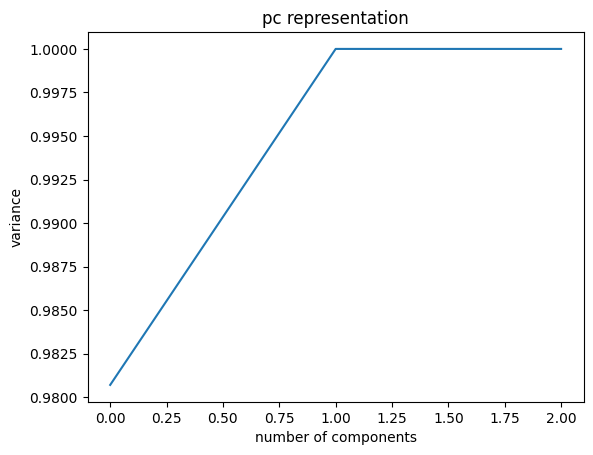

In [90]:
plt.figure()
plt.plot(np.cumsum(var))
plt.xlabel("number of components")
plt.ylabel("variance")
plt.title("pc representation")
plt.show()